<a href="https://colab.research.google.com/github/chasimarshad-bot/26-dbc/blob/main/Iris_ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training a Simple Machine Learning Model
This notebook demonstrates how to load a dataset, preprocess it, train a model using `scikit-learn`, and evaluate its performance.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

print("Features preview:")
display(X.head())
print("Target classes:", iris.target_names)

Features preview:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Target classes: ['setosa' 'versicolor' 'virginica']


In [2]:
# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [3]:
# 4. Make predictions and evaluate
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Feature Importances:


,Feature,Importance
2,petal length (cm),0.439994
3,petal width (cm),0.421522
0,sepal length (cm),0.108098
1,sepal width (cm),0.030387


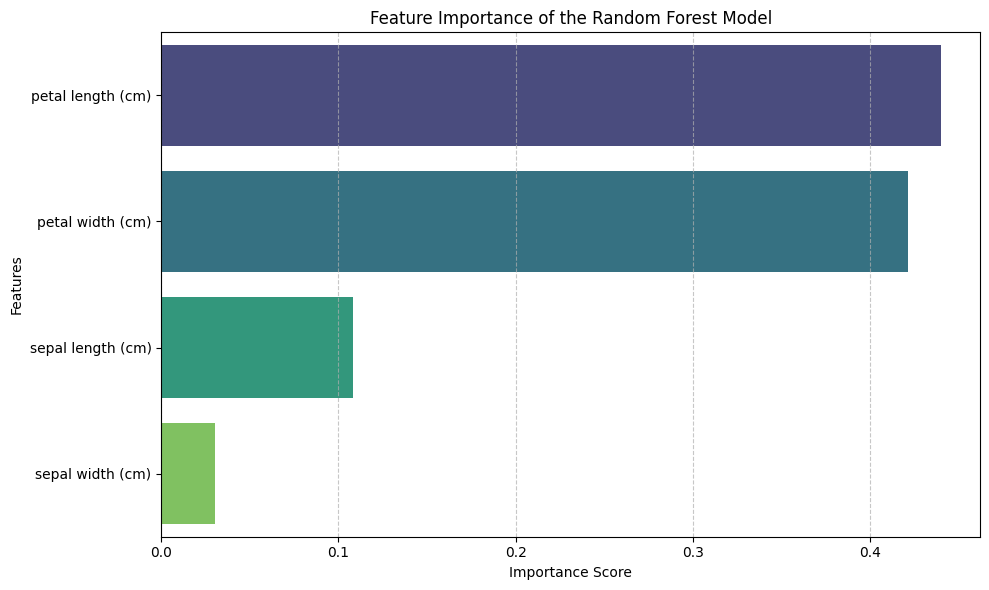

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
display(feature_imp_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance of the Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

=== Decision Tree Performance ===
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


=== Decision Tree Feature Importances ===


,Feature,Importance
2,petal length (cm),0.906143
3,petal width (cm),0.077186
1,sepal width (cm),0.016670
0,sepal length (cm),0.000000


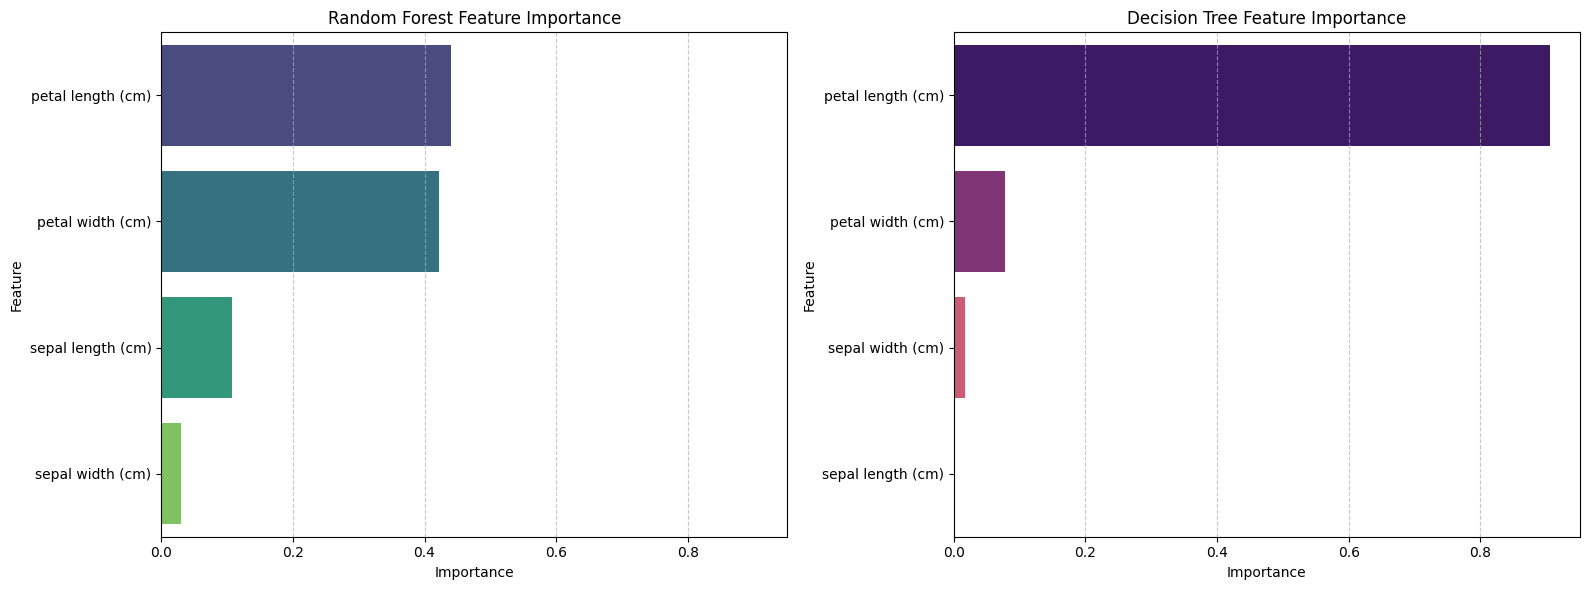

In [5]:
from sklearn.tree import DecisionTreeClassifier

# 1. Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Make predictions and evaluate
dt_y_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_y_pred)

print("=== Decision Tree Performance ===")
print(f"Accuracy: {dt_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, dt_y_pred, target_names=iris.target_names))

# 3. Extract and display feature importances for comparison
dt_importances = dt_model.feature_importances_
dt_feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_importances
}).sort_values(by='Importance', ascending=False)

print("\n=== Decision Tree Feature Importances ===")
display(dt_feature_imp_df)

# 4. Compare feature importances of both models in a plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

sns.barplot(ax=axes[0], x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
axes[0].set_title('Random Forest Feature Importance')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

sns.barplot(ax=axes[1], x='Importance', y='Feature', data=dt_feature_imp_df, palette='magma', hue='Feature', legend=False)
axes[1].set_title('Decision Tree Feature Importance')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

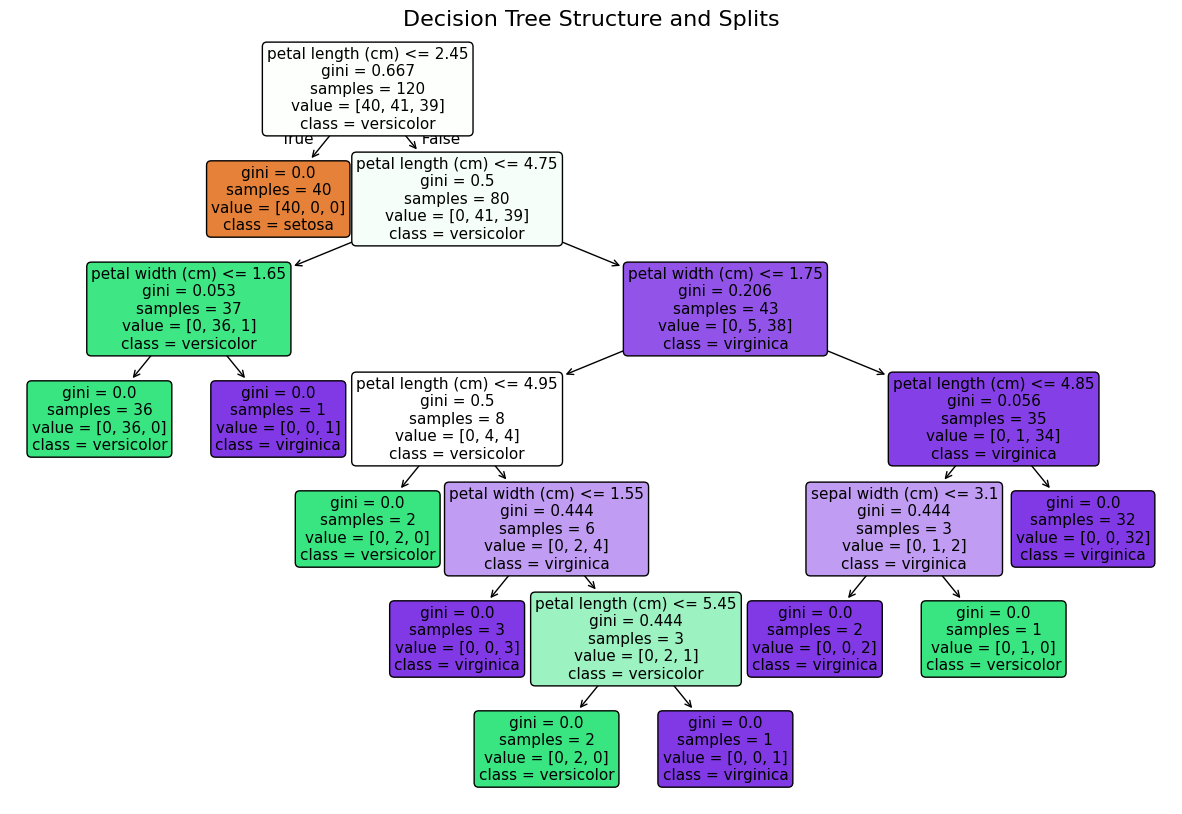

In [6]:
from sklearn.tree import plot_tree

# Set a clean figure size for the tree visualization
plt.figure(figsize=(15, 10))

# Plot the decision tree structure
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=11
)

plt.title("Decision Tree Structure and Splits", fontsize=16)
plt.show()

In [7]:
# 1. Initialize models to train on the full dataset
rf_full = RandomForestClassifier(n_estimators=100, random_state=42)
dt_full = DecisionTreeClassifier(random_state=42)

# 2. Fit on the full dataset
rf_full.fit(X, y)
dt_full.fit(X, y)

# 3. Predict on the full dataset
rf_full_pred = rf_full.predict(X)
dt_full_pred = dt_full.predict(X)

# 4. Evaluate and compare performance
rf_full_acc = accuracy_score(y, rf_full_pred)
dt_full_acc = accuracy_score(y, dt_full_pred)

print("=== Performance on the Full Dataset (No Split) ===")
print(f"Random Forest Full-set Accuracy: {rf_full_acc:.4f}")
print(f"Decision Tree Full-set Accuracy: {dt_full_acc:.4f}\n")

print("Random Forest Classification Report (Full Dataset):")
print(classification_report(y, rf_full_pred, target_names=iris.target_names))

print("\nDecision Tree Classification Report (Full Dataset):")
print(classification_report(y, dt_full_pred, target_names=iris.target_names))

=== Performance on the Full Dataset (No Split) ===
Random Forest Full-set Accuracy: 1.0000
Decision Tree Full-set Accuracy: 1.0000

Random Forest Classification Report (Full Dataset):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       1.00      1.00      1.00        50
   virginica       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


Decision Tree Classification Report (Full Dataset):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       1.00      1.00      1.00        50
   virginica       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



### Implementing K-Fold Cross-Validation

Instead of evaluating on the full dataset (which leads to overfitting) or relying on a single train-test split, we can use **K-Fold Cross-Validation**:
1. The dataset is split into $K$ equal-sized folds.
2. The model is trained $K$ times, each time using $K-1$ folds for training and the remaining fold for testing.
3. The final performance is the average score across all $K$ iterations.

This gives a much more robust and honest estimate of how the model will perform on unseen data.

In [8]:
from sklearn.model_selection import cross_val_score

# Initialize our base classifiers again
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)
dt_cv = DecisionTreeClassifier(random_state=42)

# Perform 5-fold cross-validation
rf_scores = cross_val_score(rf_cv, X, y, cv=5)
dt_scores = cross_val_score(dt_cv, X, y, cv=5)

print("=== 5-Fold Cross-Validation Results ===")
print(f"Random Forest Scores: {rf_scores}")
print(f"Random Forest Mean Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std() * 2:.4f})")

print(f"\nDecision Tree Scores: {dt_scores}")
print(f"Decision Tree Mean Accuracy: {dt_scores.mean():.4f} (+/- {dt_scores.std() * 2:.4f})")

=== 5-Fold Cross-Validation Results ===
Random Forest Scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Random Forest Mean Accuracy: 0.9667 (+/- 0.0422)

Decision Tree Scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Decision Tree Mean Accuracy: 0.9533 (+/- 0.0680)


### Why does the Decision Tree have a higher Standard Deviation?

In our cross-validation results, we observed:
- **Random Forest Standard Deviation**: `0.0422` (Lower Variance)
- **Decision Tree Standard Deviation**: `0.0680` (Higher Variance)

This behavior is expected due to the fundamental structural differences between a single model and an ensemble model:

1. **High Variance of Single Decision Trees**:
   Decision Trees are highly sensitive to the specific training data they receive. A small change in the data can result in a completely different split at the root node, which cascades down to change the entire tree structure. This sensitivity causes the model's accuracy to vary wildly from fold to fold.

2. **The Power of Ensemble Averaging (Bagging)**:
   A Random Forest reduces this variance through a technique called **Bootstrap Aggregating (Bagging)**. It trains many individual decision trees on different random subsets of both the data rows and features, and then averages their predictions.

Mathematically, if you average multiple independent or weakly correlated predictions, the variance of the average is significantly lower than the variance of any individual prediction:
$$\text{Variance}(\text{Ensemble}) \approx \frac{\text{Variance}(\text{Single Tree})}{N}$$

3. **Robustness to Outliers**:
   If a specific fold contains unique outliers, a single Decision Tree might overfit to them (causing a performance drop on that fold's test set). In contrast, the Random Forest mitigates the impact of these outliers because only a small fraction of its constituent trees will encounter them during training.

### Hyperparameter Comparison: Decision Tree vs. Random Forest

Because a **Random Forest** is an ensemble composed of many **Decision Trees**, it shares almost all of the tree-level hyperparameters while adding ensemble-specific parameters to control how the trees are built and aggregated.

| Hyperparameter | Decision Tree | Random Forest | Description |
| :--- | :--- | :--- | :--- |
| **`n_estimators`** | ❌ *No* |  **Yes** (Default: 100) | The number of trees in the forest. More trees increase robustness but take longer to train. |
| **`bootstrap`** | ❌ *No* |  **Yes** (Default: `True`) | Whether bootstrap samples (sampling with replacement) are used when building trees. |
| **`max_features`** | **Yes** (Default: `None`) | **Yes** (Default: `"sqrt"`) | The number of features to consider when looking for the best split. Forests typically restrict this to add diversity to the trees. |
| **`max_depth`** | **Yes** (Default: `None`) | **Yes** (Default: `None`) | The maximum depth of the tree(s). Restricting depth helps prevent overfitting. |
| **`min_samples_split`** | **Yes** (Default: 2) | **Yes** (Default: 2) | The minimum number of samples required to split an internal node. |
| **`min_samples_leaf`** | **Yes** (Default: 1) | **Yes** (Default: 1) | The minimum number of samples required to be at a leaf node. |
| **`n_jobs`** | ❌ *No* |  **Yes** (Default: `None`) | The number of CPU cores to use for parallel execution. Decision Trees can't run in parallel, but forests can since trees are independent. |

In [9]:
# Instantiate fresh classifiers to inspect their parameters
rf_temp = RandomForestClassifier(random_state=42)
dt_temp = DecisionTreeClassifier(random_state=42)

# Get all parameters
rf_params = rf_temp.get_params()
dt_params = dt_temp.get_params()

# Identify which parameters are unique to Random Forest
unique_to_rf = {k: v for k, v in rf_params.items() if k not in dt_params}

# Identify shared parameters (though they might have different default values)
shared_params = {k: (dt_params[k], rf_params[k]) for k in dt_params.keys() if k in rf_params}

print("=== Parameters Unique to Random Forest ===")
for k, v in unique_to_rf.items():
    print(f"{k:<20}: {v}")

print("\n=== Examples of Shared Parameters (Decision Tree Default vs. Random Forest Default) ===")
subset_shared = ['max_depth', 'min_samples_split', 'max_features', 'criterion']
for k in subset_shared:
    print(f"{k:<20} -> DT: {shared_params[k][0]} | RF: {shared_params[k][1]}")

=== Parameters Unique to Random Forest ===
bootstrap           : True
max_samples         : None
n_estimators        : 100
n_jobs              : None
oob_score           : False
verbose             : 0
warm_start          : False

=== Examples of Shared Parameters (Decision Tree Default vs. Random Forest Default) ===
max_depth            -> DT: None | RF: None
min_samples_split    -> DT: 2 | RF: 2
max_features         -> DT: None | RF: sqrt
criterion            -> DT: gini | RF: gini


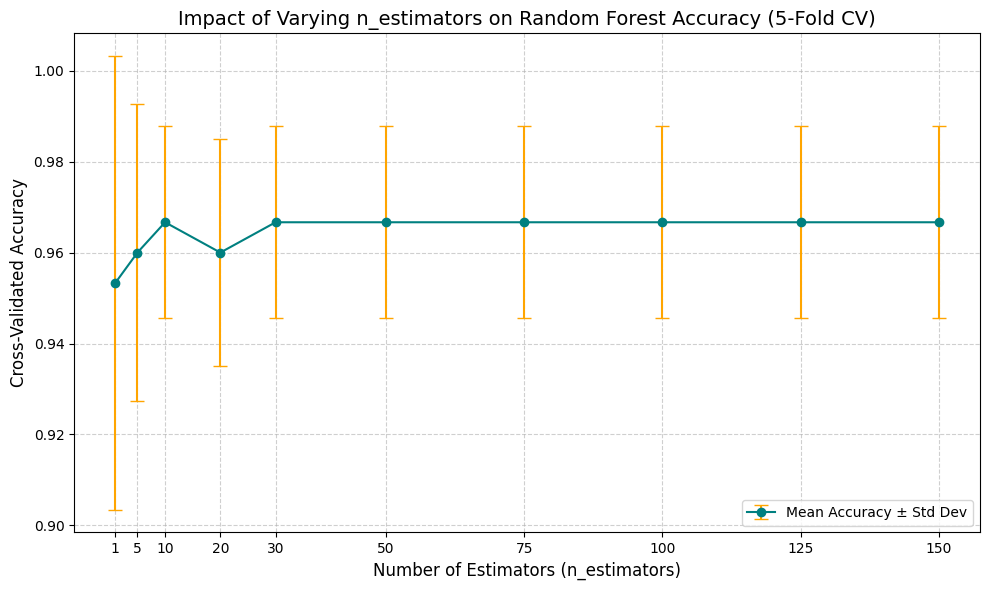

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Define the range of n_estimators to test
estimator_range = [1, 5, 10, 20, 30, 50, 75, 100, 125, 150]
cv_scores_mean = []
cv_scores_std = []

# Evaluate each n_estimators value using 5-fold CV
for n in estimator_range:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(clf, X, y, cv=5)
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

# Plot the results
plt.figure(figsize=(10, 6))
plt.errorbar(estimator_range, cv_scores_mean, yerr=cv_scores_std, fmt='-o', color='teal', ecolor='orange', capsize=5, label='Mean Accuracy ± Std Dev')
plt.title('Impact of Varying n_estimators on Random Forest Accuracy (5-Fold CV)', fontsize=14)
plt.xlabel('Number of Estimators (n_estimators)', fontsize=12)
plt.ylabel('Cross-Validated Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(estimator_range)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

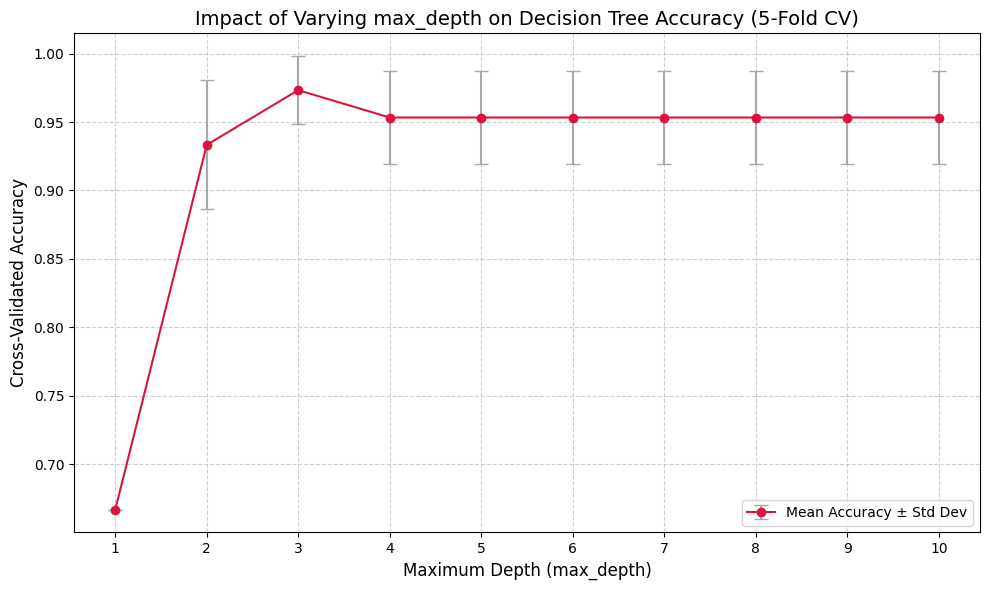

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Define the range of max_depth to test
depth_range = list(range(1, 11))
dt_cv_means = []
dt_cv_stds = []

# Evaluate each max_depth using 5-fold CV
for depth in depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(clf, X, y, cv=5)
    dt_cv_means.append(scores.mean())
    dt_cv_stds.append(scores.std())

# Plot the results
plt.figure(figsize=(10, 6))
plt.errorbar(depth_range, dt_cv_means, yerr=dt_cv_stds, fmt='-o', color='crimson', ecolor='darkgray', capsize=5, label='Mean Accuracy ± Std Dev')
plt.title('Impact of Varying max_depth on Decision Tree Accuracy (5-Fold CV)', fontsize=14)
plt.xlabel('Maximum Depth (max_depth)', fontsize=12)
plt.ylabel('Cross-Validated Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(depth_range)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 🧠 Logical Mind Flow Chart of the Machine Learning Process

Below is a visual representation of the step-by-step pipeline we executed in this notebook, starting from raw data ingestion to evaluating model variance, hyperparameter comparisons, and hyperparameter tuning:

```mermaid
graph TD
    A[1. Data Ingestion & Preprocessing] -->|Load Iris Dataset| B[Split into 80% Train / 20% Test]
    
    B --> C[2. Random Forest Pipeline]
    B --> D[3. Decision Tree Pipeline]
    
    C -->|Fit RF Classifier| E[Evaluate Test Accuracy: 100%]
    D -->|Fit DT Classifier| F[Evaluate Test Accuracy: 100%]
    
    E --> G[Extract & Plot Feature Importances]
    F --> H[Extract & Plot Feature Importances]
    
    G -->|Shared Feature Importances| I[Compare Feature importances side-by-side]
    H -->|Focused on Petal Length| I
    
    I --> J[4. Tree Structure Analysis]
    J -->|Visualize Root & Leaf Splits| K[Analyze Decision Boundaries & Cuts]
    
    K --> L[5. Overfitting & Robustness Check]
    L -->|Evaluate on Full Dataset| M[Both Score 100% - Clear Overfitting Risk]
    
    M -->|Mitigation| N[6. K-Fold Cross-Validation]
    N -->|5-Fold CV Accuracy| O[Compare Mean & Variance]
    O -->|RF Mean: 96.67% / Std: 0.0422| P[Explain Ensemble Bagging Variance Reduction]
    O -->|DT Mean: 95.33% / Std: 0.0680| P
    
    P --> Q[7. Hyperparameter Inspection]
    Q -->|Identify Shared vs Unique| R[Analyze n_estimators, max_depth, bootstrap]
    
    R --> S[8. Hyperparameter Sweeps]
    S -->|Vary n_estimators| T[Plot RF CV Accuracy Plateau]
    S -->|Vary max_depth| U[Plot DT CV Accuracy Peak & Overfit]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style O fill:#bbf,stroke:#333,stroke-width:2px
    style S fill:#bfb,stroke:#333,stroke-width:2px
```

### 9. Hyperparameter Tuning with Grid Search

To find the optimal combination of hyperparameters simultaneously (instead of checking them one-by-one), we use **Grid Search with Cross-Validation (`GridSearchCV`)**.

We will explore a grid combining:
- **`max_depth`**: $[1, 2, 3, 4, 5, 6, 8, 10]$
- **`min_samples_split`**: $[2, 3, 5, 10, 20]$

In [12]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 3, 5, 10, 20]
}

# 2. Initialize the base Decision Tree Classifier
dt_base = DecisionTreeClassifier(random_state=42)

# 3. Instantiate GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

# 4. Fit Grid Search on the entire dataset
grid_search.fit(X, y)

# 5. Extract results
print("=== Grid Search Results ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best 5-Fold CV Accuracy: {grid_search.best_score_:.4f}\n")

# Convert results to a DataFrame for visualization
cv_results_df = pd.DataFrame(grid_search.cv_results_)
pivot_df = cv_results_df.pivot(index='param_max_depth', columns='param_min_samples_split', values='mean_test_score')

print("Mean Test Scores (Accuracy) Grid:")
display(pivot_df)

=== Grid Search Results ===
Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best 5-Fold CV Accuracy: 0.9733

Mean Test Scores (Accuracy) Grid:


param_min_samples_split,2,3,5,10,20
param_max_depth,,,,,
1,0.666667,0.666667,0.666667,0.666667,0.666667
2,0.933333,0.933333,0.933333,0.933333,0.933333
3,0.973333,0.973333,0.973333,0.973333,0.973333
4,0.953333,0.953333,0.966667,0.966667,0.966667
5,0.953333,0.953333,0.966667,0.966667,0.966667
6,0.953333,0.953333,0.966667,0.966667,0.966667
8,0.953333,0.953333,0.966667,0.966667,0.966667
10,0.953333,0.953333,0.966667,0.966667,0.966667


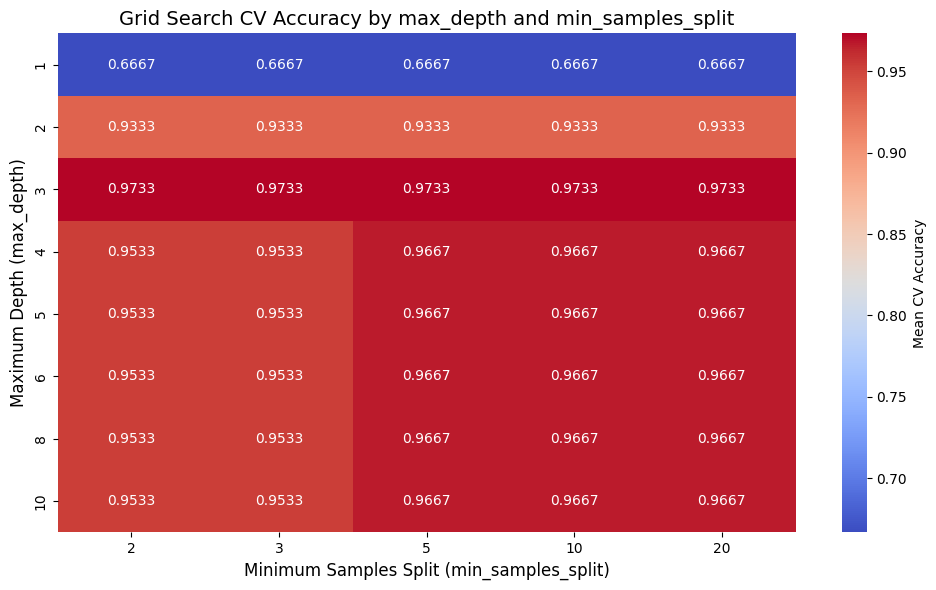

In [13]:
# 6. Visualize the Grid Search results with a Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='.4f', cmap='coolwarm', cbar_kws={'label': 'Mean CV Accuracy'})
plt.title('Grid Search CV Accuracy by max_depth and min_samples_split', fontsize=14)
plt.xlabel('Minimum Samples Split (min_samples_split)', fontsize=12)
plt.ylabel('Maximum Depth (max_depth)', fontsize=12)
plt.tight_layout()
plt.show()

### 📊 Grid Search Cross-Validation Flow Chart

This flowchart illustrates how the `GridSearchCV` process systematically evaluated every combination of `max_depth` and `min_samples_split` using 5-fold cross-validation to isolate the optimal model parameters:

```mermaid
graph TD
    A[Start Grid Search] --> B[Define Hyperparameter Space]
    B --> C[max_depth: 1, 2, 3, 4, 5, 6, 8, 10]
    B --> D[min_samples_split: 2, 3, 5, 10, 20]
    
    C --> E[Generate Grid: 8 x 5 = 40 Unique Combinations]
    D --> E
    
    E --> F[For each parameter combination...]
    F --> G[Split dataset into 5 Folds]
    
    G --> H[Loop 5 times: Train on 4 folds, Validate on 1 fold]
    H --> I[Calculate Mean CV Accuracy & Standard Deviation]
    
    I --> J{All 40 combinations processed?}
    J -->|No| F
    J -->|Yes| K[Compare results on performance heatmap]
    
    K --> L[Identify Best Parameters:<br/>max_depth = 3<br/>min_samples_split = 2]
    L --> M[Export Final Optimized Decision Tree Model]

    style A fill:#f9f,stroke:#333,stroke-width:2px
    style L fill:#bbf,stroke:#333,stroke-width:2px
    style M fill:#bfb,stroke:#333,stroke-width:2px
```

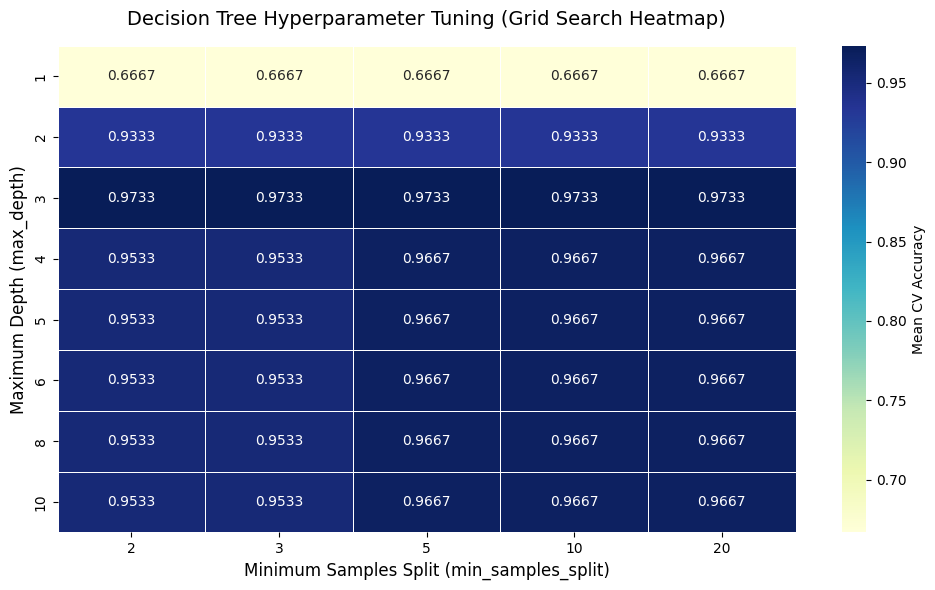

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data from grid search results
pivot_df = cv_results_df.pivot(index='param_max_depth', columns='param_min_samples_split', values='mean_test_score')

# Create a high-quality heatmap visualization
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Mean CV Accuracy'}
)

plt.title('Decision Tree Hyperparameter Tuning (Grid Search Heatmap)', fontsize=14, pad=15)
plt.xlabel('Minimum Samples Split (min_samples_split)', fontsize=12)
plt.ylabel('Maximum Depth (max_depth)', fontsize=12)
plt.tight_layout()
plt.show()